## 基于 Pytorch 的线性回归和逻辑回归

In [470]:
import torch
import numpy
import matplotlib.pyplot
import pandas

matplotlib.pyplot.style.use("matplotlib.mplstyle")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### 一元线性回归构建

In [471]:
DATASET = pandas.read_csv("data/202501061035.csv")

X = (DATASET[["size", "rooms"]]).astype(float).to_numpy()
Y = (DATASET["price"]).astype(float).to_numpy()

X[:, 0] = X[:, 0] / 1000
Y = Y / 1000

X = torch.from_numpy(X).type(torch.float32).to(DEVICE)
Y = torch.from_numpy(Y).type(torch.float32).to(DEVICE).unsqueeze(1)

In [472]:
# 定义线性回归模型
MODEL = torch.nn.Linear(in_features=1, out_features=1).to(DEVICE)

# 定义损失函数和优化器
CRITERION = torch.nn.MSELoss()
OPTIMIZER = torch.optim.SGD(MODEL.parameters(), lr=0.01)

# 手动训练
HISTORY = []
EPOCHS = 200
for epoch in range(EPOCHS):
    pred = MODEL(X[:, 0].unsqueeze(1)) # 前向传播
    loss = CRITERION(pred, Y)          # 损失计算
    OPTIMIZER.zero_grad()              # 清除梯度
    loss.backward()                    # 计算梯度
    OPTIMIZER.step()                   # 更新参数
    if (epoch + 1) % 10 == 0:
        dict = MODEL.state_dict()
        fw = dict["weight"].cpu().detach().numpy()
        fb = dict["bias"].cpu().detach().numpy()
        HISTORY.append([fw[0][0], fb[0], loss.item()])
        print(f"Cost is {loss:.4e}, Weights is {fw[0][0]:.4e}, Bias is {fb[0]:.4e}")

HISTORY = torch.from_numpy(numpy.array(HISTORY)).type(torch.float32)

DICT = MODEL.state_dict()
FW = dict["weight"].cpu().detach().numpy()
FB = dict["bias"].cpu().detach().numpy()

Cost is 1.9770e+04, Weights is 9.5363e+01, Bias is 4.2622e+01
Cost is 5.6427e+03, Weights is 1.2512e+02, Bias is 5.6078e+01
Cost is 4.2739e+03, Weights is 1.3432e+02, Bias is 6.0406e+01
Cost is 4.1409e+03, Weights is 1.3712e+02, Bias is 6.1889e+01
Cost is 4.1276e+03, Weights is 1.3794e+02, Bias is 6.2483e+01
Cost is 4.1260e+03, Weights is 1.3813e+02, Bias is 6.2799e+01
Cost is 4.1254e+03, Weights is 1.3814e+02, Bias is 6.3025e+01
Cost is 4.1250e+03, Weights is 1.3808e+02, Bias is 6.3219e+01
Cost is 4.1246e+03, Weights is 1.3801e+02, Bias is 6.3402e+01
Cost is 4.1242e+03, Weights is 1.3794e+02, Bias is 6.3578e+01
Cost is 4.1239e+03, Weights is 1.3786e+02, Bias is 6.3749e+01
Cost is 4.1236e+03, Weights is 1.3779e+02, Bias is 6.3916e+01
Cost is 4.1232e+03, Weights is 1.3772e+02, Bias is 6.4080e+01
Cost is 4.1229e+03, Weights is 1.3765e+02, Bias is 6.4239e+01
Cost is 4.1226e+03, Weights is 1.3758e+02, Bias is 6.4396e+01
Cost is 4.1224e+03, Weights is 1.3751e+02, Bias is 6.4548e+01
Cost is 

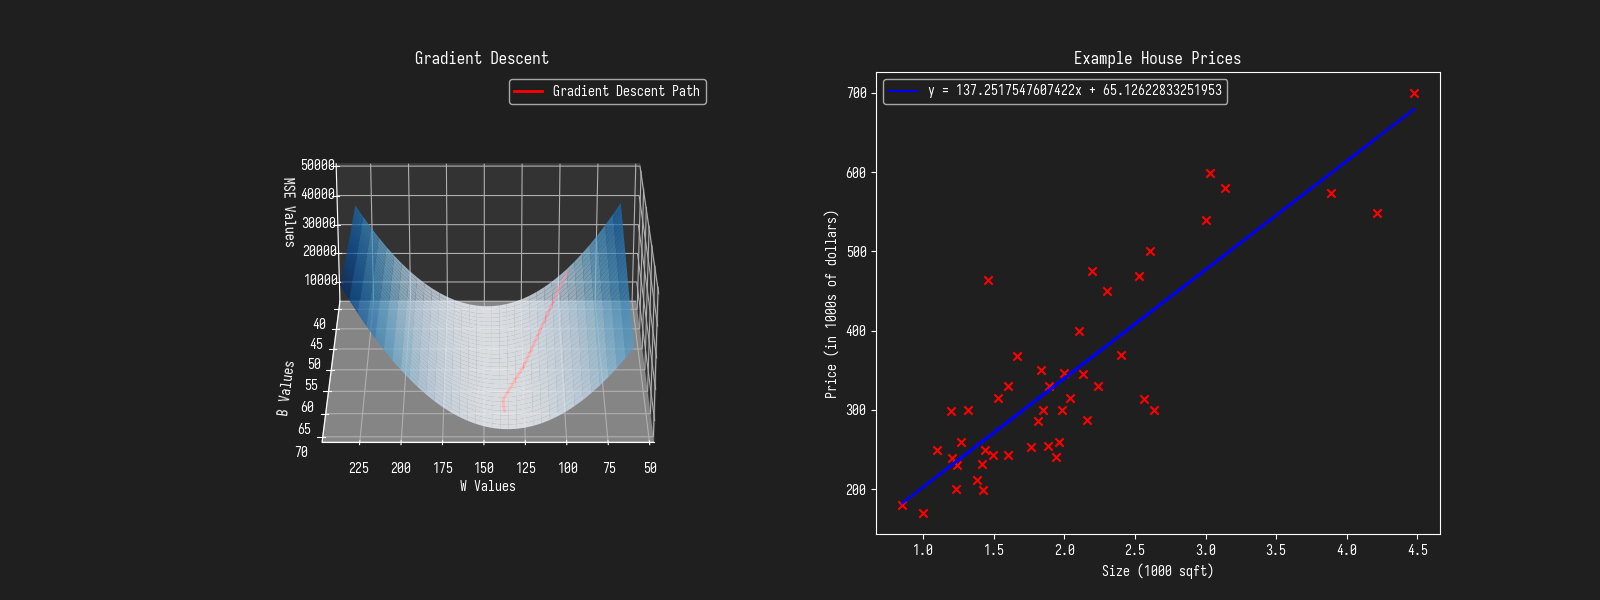

In [473]:
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}

W = torch.arange(60, 240, 5).type(torch.float32).to(DEVICE)
B = torch.arange(40, 70, 1).type(torch.float32).to(DEVICE)
W, B = torch.meshgrid(W, B)

def compute_cost(w, b):
    costs = []
    for i in range(w.shape[0]):
        predictions = w[i] * X[:, 0].unsqueeze(1) + b[i]
        costs.append(CRITERION(predictions, Y))
    return torch.stack(costs)

Z = torch.vmap(compute_cost, in_dims=(0, 0))(W, B)

X = X.cpu().detach().numpy()
Y = Y.cpu().detach().numpy()
W = W.cpu().detach().numpy()
B = B.cpu().detach().numpy()
Z = Z.cpu().detach().numpy()

figure = matplotlib.pyplot.figure(figsize=(16, 6))
axes1 = figure.add_subplot(1, 2, 1, projection="3d")
surface = axes1.plot_surface(W, B, Z, cmap=matplotlib.cm.Blues, alpha=0.75)

axes1.view_init(elev=25, azim=90, roll=0)
axes1.set_title("Gradient Descent")
axes1.set_xlabel("W Values")
axes1.set_ylabel("B Values")
axes1.set_zlabel("MSE Values", labelpad=10)

tws, tbs, mse = HISTORY[:, 0], HISTORY[:, 1], HISTORY[:, 2]
axes1.plot3D(tws, tbs, mse, color="red", linewidth=2, label="Gradient Descent Path")
axes1.legend()
axes1.set_box_aspect([2, 2, 1])

axes2 = figure.add_subplot(1, 2, 2)

axes2.scatter(X[:, 0], Y, marker="x", c="r")
axes2.plot(X[:, 0], FW[0][0] * X[:, 0] + FB[0], color="blue", label=f"y = {FW[0][0]}x + {FB[0]}")
axes2.set_title("Example House Prices")
axes2.set_xlabel("Size (1000 sqft)")
axes2.set_ylabel("Price (in 1000s of dollars)")
axes2.legend()

matplotlib.pyplot.show()

### 一元逻辑回归构建

In [474]:
DATASET = pandas.read_csv("data/202503081558.csv")

X = (DATASET[["C1", "C2"]]).astype(float).to_numpy()
Y = (DATASET["LABEL"]).astype(float).to_numpy()

X = X / 100

X = torch.from_numpy(X).float().to(DEVICE)
Y = torch.from_numpy(Y).unsqueeze(1).float().to(DEVICE)

print(f"X shape is {X.shape}, Y shape is {Y.shape}")

X shape is torch.Size([100, 2]), Y shape is torch.Size([100, 1])


In [475]:
# 定义逻辑回归模型
class LogisticRegression(torch.nn.Module):
    def __init__(self):
        super(LogisticRegression, self).__init__()
        self.linear = torch.nn.Linear(2, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))
    
MODEL = LogisticRegression().to(DEVICE)

# 定义损失函数和优化器
CRITERION = torch.nn.BCELoss()
OPTIMIZER = torch.optim.Adam(MODEL.parameters(), lr=0.2)

# 手动训练
HISTORY = []
EPOCHS = 1000
for epoch in range(EPOCHS):
    pred = MODEL(X) # 前向传播
    loss = CRITERION(pred, Y) # 损失计算
    OPTIMIZER.zero_grad() # 清除梯度
    loss.backward() # 计算梯度
    OPTIMIZER.step() # 更新参数
    if (epoch + 1) % 10 == 0:
        dict = MODEL.state_dict()
        fw = dict["linear.weight"].cpu().detach().numpy()
        fb = dict["linear.bias"].cpu().detach().numpy()
        HISTORY.append([fw[0][0], fw[0][1], fb[0], loss.item()])

print(pandas.DataFrame(HISTORY, columns=["WEIGHT0", "WEIGHT1", "BIAS", "LOSS"]).to_string(formatters={'WEIGHT0': '{:.4e}'.format, 'WEIGHT1': '{:.4e}'.format, 'BIAS': '{:.4e}'.format, 'LOSS': '{:.4e}'.format}))

HISTORY = torch.from_numpy(numpy.array(HISTORY)).float()



      WEIGHT0    WEIGHT1        BIAS       LOSS
0  1.2812e+00 6.5199e-01 -9.3141e-01 5.8635e-01
1  2.2590e+00 1.5425e+00 -1.8299e+00 5.2327e-01
2  3.0856e+00 2.3118e+00 -2.9539e+00 4.6581e-01
3  3.8832e+00 3.0982e+00 -4.0539e+00 4.2007e-01
4  4.6776e+00 3.9165e+00 -5.0339e+00 3.8365e-01
5  5.3793e+00 4.6567e+00 -5.9576e+00 3.5534e-01
6  6.0120e+00 5.3271e+00 -6.8109e+00 3.3322e-01
7  6.6076e+00 5.9514e+00 -7.5803e+00 3.1565e-01
8  7.1617e+00 6.5231e+00 -8.2867e+00 3.0150e-01
9  7.6746e+00 7.0452e+00 -8.9438e+00 2.8988e-01
10 8.1557e+00 7.5307e+00 -9.5543e+00 2.8020e-01
11 8.6087e+00 7.9863e+00 -1.0124e+01 2.7203e-01
12 9.0348e+00 8.4148e+00 -1.0660e+01 2.6505e-01
13 9.4368e+00 8.8197e+00 -1.1166e+01 2.5902e-01
14 9.8182e+00 9.2043e+00 -1.1646e+01 2.5378e-01
15 1.0181e+01 9.5704e+00 -1.2101e+01 2.4918e-01
16 1.0527e+01 9.9195e+00 -1.2535e+01 2.4512e-01
17 1.0857e+01 1.0253e+01 -1.2950e+01 2.4152e-01
18 1.1173e+01 1.0573e+01 -1.3347e+01 2.3831e-01
19 1.1477e+01 1.0879e+01 -1.3727e+01 2.3

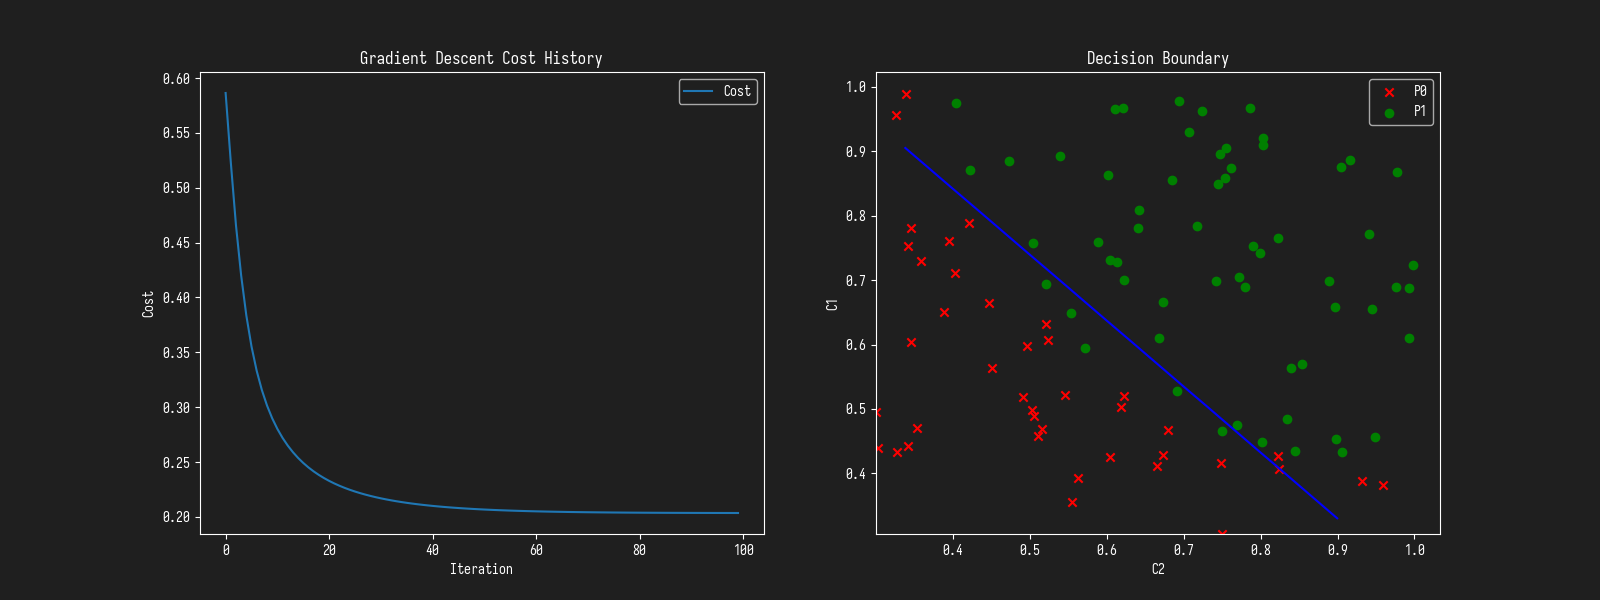

In [476]:
figure = matplotlib.pyplot.figure(figsize=(16, 6))
axes1 = figure.add_subplot(1, 2, 1)
axes1.plot(HISTORY[:, 3], label="Cost")
axes1.set_title("Gradient Descent Cost History")
axes1.set_ylabel("Cost")
axes1.set_xlabel("Iteration")
axes1.legend()

X = X.cpu().detach().numpy()
Y = Y.cpu().detach().numpy()

XMIN1, XMAX1 = X[:, 0].min(), X[:, 0].max()
XMIN2, XMAX2 = X[:, 1].min(), X[:, 1].max()
XX1, XX2 = torch.meshgrid(torch.arange(XMIN1, XMAX1, 0.1), torch.arange(XMIN2, XMAX2, 0.1))
GRID = torch.stack([XX1, XX2], axis=-1).reshape(-1, 2).to(DEVICE)

with torch.no_grad():
    PROBS = MODEL.forward((GRID).squeeze())

PROBS = PROBS.cpu().detach().numpy()

MASK0 = (Y == 0).squeeze() # 布尔掩码 Y = 0
MASK1 = (Y == 1).squeeze() # 布尔掩码 Y = 1

axes2 = figure.add_subplot(1, 2, 2)
axes2.scatter(X[MASK0, 0], X[MASK0, 1], marker="x", c="r", label="P0")
axes2.scatter(X[MASK1, 0], X[MASK1, 1], marker="o", c="g", label="P1")
axes2.contour(XX1, XX2, PROBS.reshape(7, 7), levels=[0.5], colors="b")
axes2.set_title("Decision Boundary")
axes2.set_ylabel("C1")
axes2.set_xlabel("C2")
axes2.legend()

matplotlib.pyplot.show()

In [477]:
features = [50.534788289883 / 100, 48.85581152764205 / 100]
SAMPLE = torch.from_numpy(numpy.array(features)).float().to(DEVICE)

with torch.no_grad():
    label = MODEL(SAMPLE).item()

print(f"Logistic for {features[0]} C1 and {features[1]} C2 is Label: {label}")

Logistic for 0.5053478828988299 C1 and 0.48855811527642046 C2 is Label: 0.008522238582372665
